In [1]:
from fmsae_repro import MODELS, LEGACY_ANALYSIS, load_manifest

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['pdf.fonttype'] = 42

### Training FM-SAE (SAE1) model

After preprocessing the whole slide H&E images and embedding image patches with UNI foundation model, the next step is to train an SAE model using the patch-level CLS embeddings. This notebook shows how to reproduce the training of SAE1 used in the manuscript. The training code are implemented in the `mesoslide` package.

In [2]:
import ezslide
import lazyslide as zs
import mesoslide as ms
import pandas as pd
import joblib 


First, we will load the slides, which now will contain the patch embeddings

In [3]:
manifest = load_manifest()
slides = ezslide.open_slides(manifest, attach_images=False)

0it [00:00, ?it/s]

40it [01:04,  1.60s/it]


Next, we initialize an SAE model with 64x expansion, and since UNI FM embedding is 1,024 dimensional, this gives an initial dictionary with 65,536 features. We will fit the model using all loaded slides. It's advised to train the model using GPU (specified by `device='cuda'`) which should complete in about 3-5 minutes.

In [4]:
from mesoslide.tools.sparse_coding._sae import SparseAutoencoder

sae = SparseAutoencoder(
    expansion_factor=64,
    batch_size=2048,
    num_steps=2000,
    min_lambda=1e-6,
    max_lambda=5,
    target_sparsity=0.001,
    learning_rate=5e-5,
    random_state=0,
)
sae.fit(slides, obsm_key="UNI_embedding", tile_key="tiles", 
        device='cuda:1', verbose=100)
joblib.dump(sae, MODELS / "SAE" / "sae_model_demo.joblib")


(2007406, 1024)
Using device: cuda:1
(2007406, 1024)
Scale factor: tensor(0.1444)


  0%|          | 0/3 [00:00<?, ?it/s]


Step 0, epoch 0
Total Loss: 0.1090
Recon Loss: 0.0145
Sparsity Loss: 0.0945
Sparsity (L0): 0.4996
Learning rate: 5.00e-05
Lambda: 1.05e-06

Step 100, epoch 0
Total Loss: 0.0297
Recon Loss: 0.0290
Sparsity Loss: 0.0007
Sparsity (L0): 0.0010
Learning rate: 5.00e-05
Lambda: 1.00e-06

Step 200, epoch 0
Total Loss: 0.0252
Recon Loss: 0.0189
Sparsity Loss: 0.0063
Sparsity (L0): 0.0011
Learning rate: 5.00e-05
Lambda: 1.34e-06

Step 300, epoch 0
Total Loss: 0.0241
Recon Loss: 0.0175
Sparsity Loss: 0.0066
Sparsity (L0): 0.0009
Learning rate: 5.00e-05
Lambda: 1.34e-06

Step 400, epoch 0
Total Loss: 0.0228
Recon Loss: 0.0163
Sparsity Loss: 0.0065
Sparsity (L0): 0.0008
Learning rate: 5.00e-05
Lambda: 1.15e-06

Step 500, epoch 0
Total Loss: 0.0213
Recon Loss: 0.0152
Sparsity Loss: 0.0061
Sparsity (L0): 0.0008
Learning rate: 5.00e-05
Lambda: 1.00e-06

Step 600, epoch 0
Total Loss: 0.0208
Recon Loss: 0.0146
Sparsity Loss: 0.0062
Sparsity (L0): 0.0007
Learning rate: 5.00e-05
Lambda: 1.00e-06

Step 70

['/n/scratch/users/z/ziz531/analysis_meson/TB/3D_HnE_reproduction_mesoslide/models/SAE/sae_model_demo.joblib']

Now we apply the trained model to all slides to get feature scores for all SAE features

In [5]:
for _, slide in slides.items():
    ms.tl.feature_extraction(
        slide,
        model="uni",
        tile_key="tiles",
        key_added="UNI_embedding",
        sparse=True,
        sparse_transform=sae.transform,
        sparse_key_added="UNI_SAE_demo",
        save=False,
    )

Running model stages: 0it [00:00, ?it/s]

  0%|          | 0/24 [00:00<?, ?it/s]

Running model stages: 0it [00:00, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

Running model stages: 0it [00:00, ?it/s]

...

  0%|          | 0/24 [00:00<?, ?it/s]

Running model stages: 0it [00:00, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

Running model stages: 0it [00:00, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

Activation stats: 0it [00:00, ?it/s]

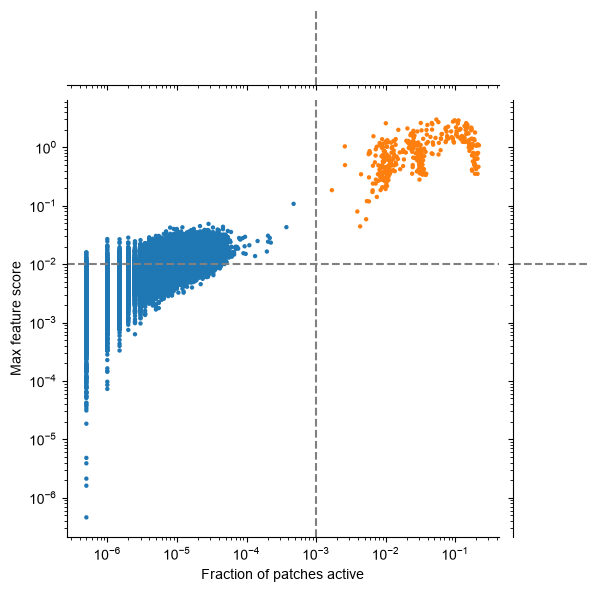

In [6]:
from mesoslide.tools import FeatureSelector

selector = FeatureSelector(
    pct_threshold=0.001,
    max_score_threshold=0.01,
    n_chunks=40
)
selector.compute_activation_stats(slides, 
                                  feature_prefix='UNI_SAE_demo', 
                                  num_features=65536)
g = selector.plot_feature_selection()


In [7]:
highly_active_features_idx = selector.get_selected_indices()
len(highly_active_features_idx)

356

In [8]:
# Cluster
from mesoslide.tools import FeatureClusterer

clusterer = FeatureClusterer(high_activation_threshold=0.5)
clusterer.compute_iou(slides, feature_prefix='UNI_SAE_demo',
                      feature_indices=highly_active_features_idx)
clusterer.cluster(threshold=25, criterion='maxclust')

IoU pass 1/2 (column max): 0it [00:00, ?it/s]

IoU pass 2/2 (accumulate): 0it [00:00, ?it/s]

Number of clusters: 25


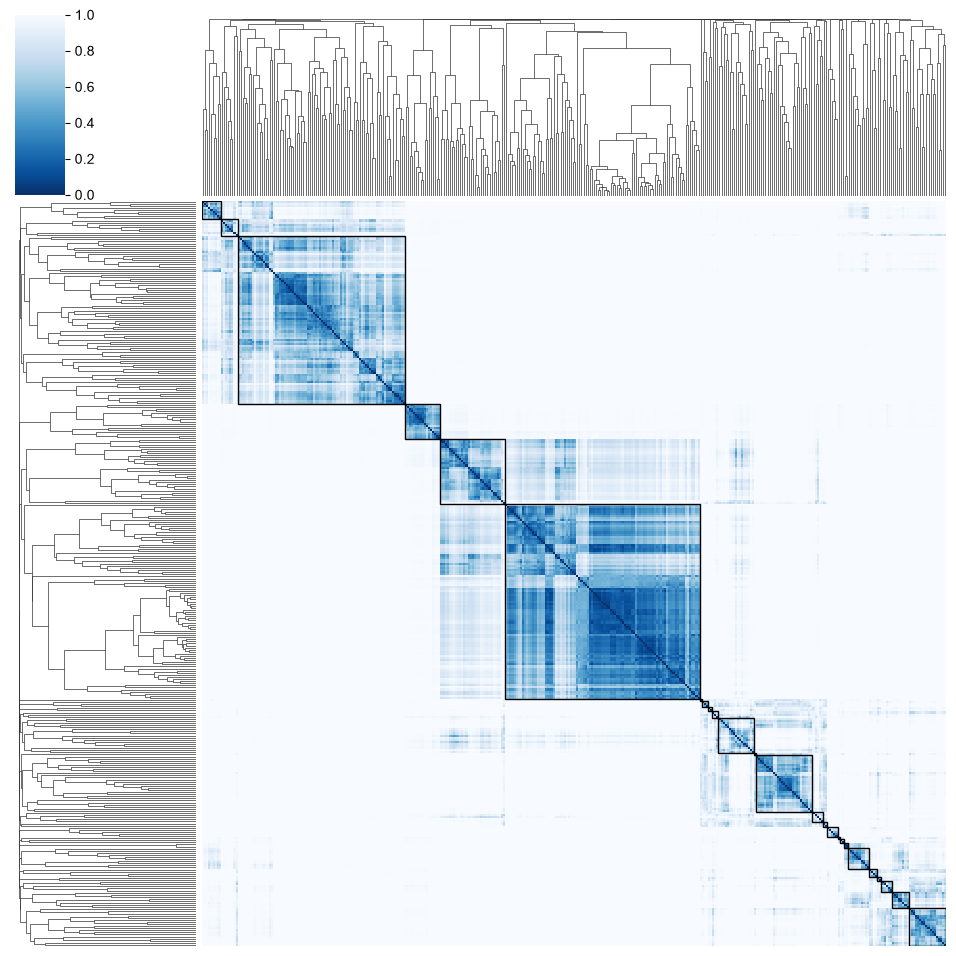

In [9]:
g = clusterer.plot_heatmap()


In [10]:
_ = clusterer.select_exemplars(slides)

  0%|          | 0/356 [00:00<?, ?it/s]

Extracting patches:   0%|          | 0/356 [00:00<?, ?it/s]

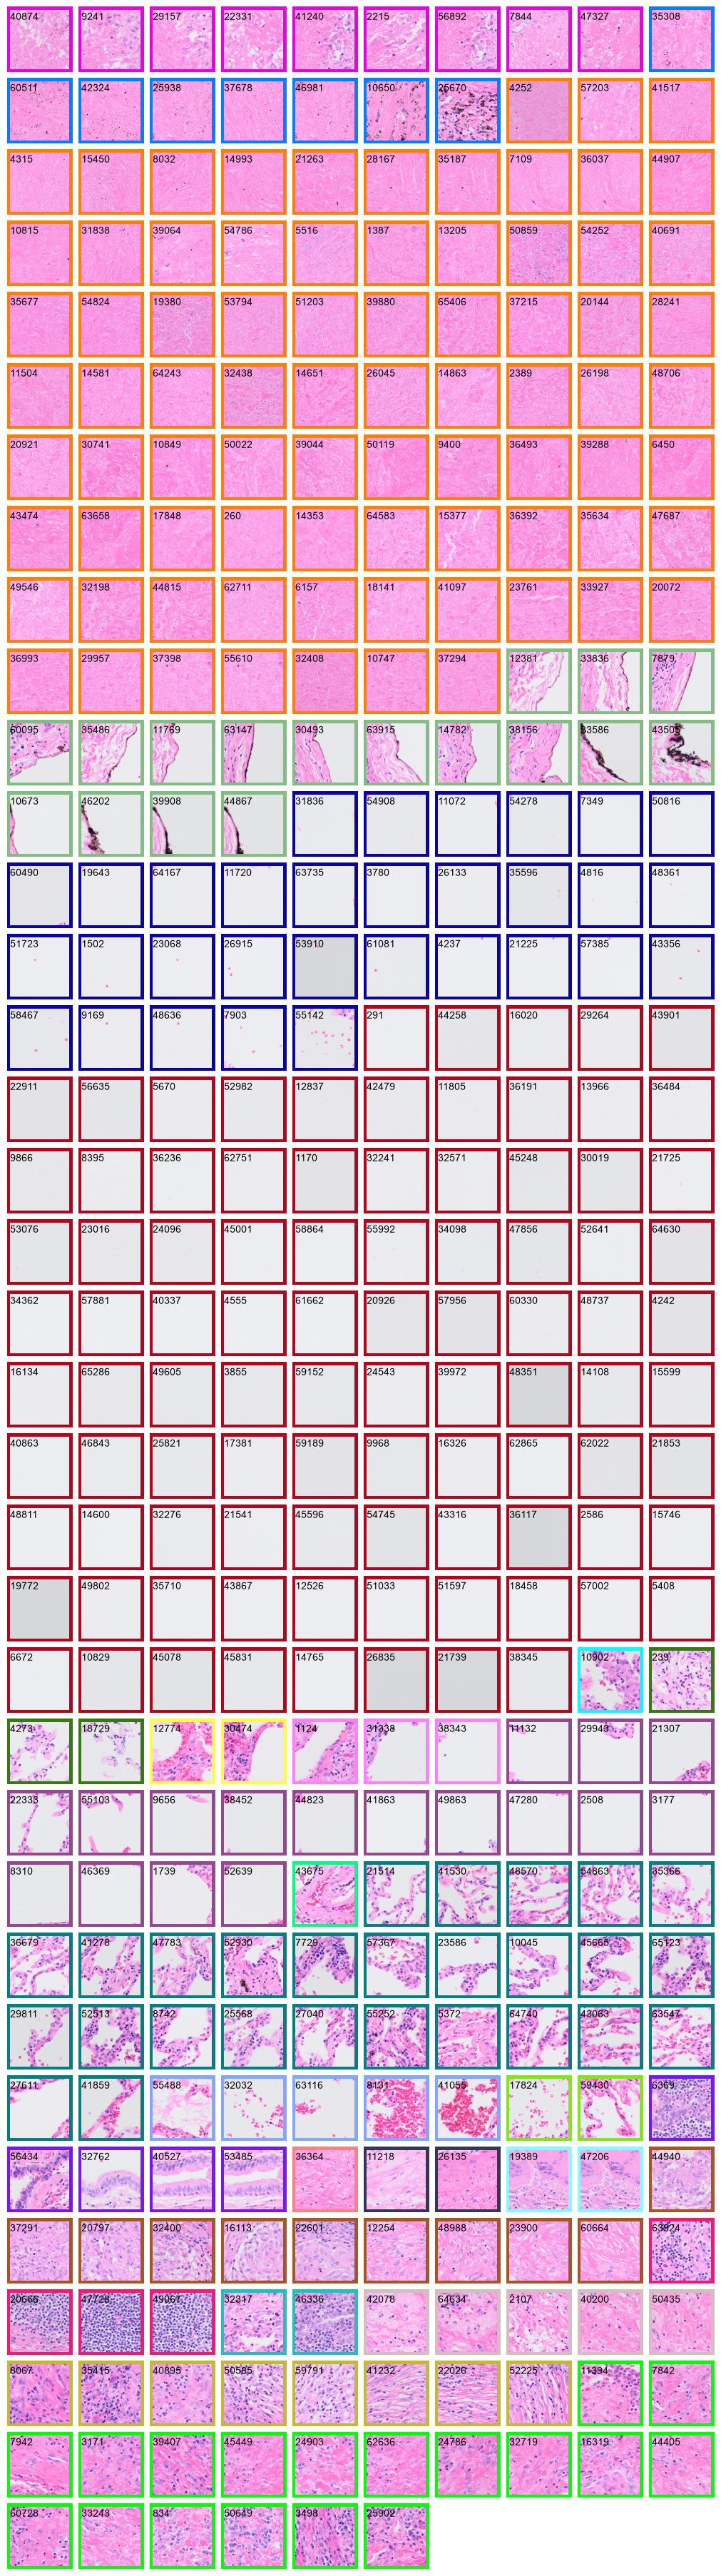

In [11]:
import distinctipy
from matplotlib.colors import ListedColormap

cmap = ListedColormap(distinctipy.get_colors(25, rng=43))

fig, axs = clusterer.plot_feature_gallery(
    cmap=cmap,
    fontsize=10,
    return_fig=True,
)